In [ ]:
!pip install -q ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import shutil
import yaml
from tqdm.auto import tqdm

In [ ]:
train_images_dir = '/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/predictions/Segm/Unet/train'
train_labels_dir = "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/YOLO_format/train/labels"

val_images_dir = '/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/predictions/Segm/Unet/test'
val_labels_dir = "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/YOLO_format/val/labels"

In [ ]:
def copy_label_with_optional_shift(src_label_path, dst_label_path, class_shift=0):
    dst_label_path.parent.mkdir(parents=True, exist_ok=True)

    if not src_label_path.exists():
        dst_label_path.write_text("")
        return

    new_lines = []

    with open(src_label_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                print(f"Пропущена некорректная строка в {src_label_path}: {line}")
                continue

            class_id = int(float(parts[0])) - class_shift
            if class_id < 0:
                raise ValueError(
                    f"После class_shift получился отрицательный class_id={class_id}. "
                    f"Файл: {src_label_path}, строка: {line}"
                )
            coords = parts[1:]
            coords_float = list(map(float, coords))
            if not all(0.0 <= x <= 1.0 for x in coords_float):
                print(f"WARNING: координаты вне [0, 1] в файле {src_label_path}: {line}")
            new_lines.append(f"{class_id} {' '.join(coords)}\n")

    with open(dst_label_path, "w") as out_f:
        out_f.writelines(new_lines)

In [ ]:
def prepare_yolo_split(
    src_images_dir, src_labels_dir, dst_images_dir, dst_labels_dir,
    image_ext=".png", class_shift=0,
):
    src_images_dir = Path(src_images_dir)
    src_labels_dir = Path(src_labels_dir)
    dst_images_dir = Path(dst_images_dir)
    dst_labels_dir = Path(dst_labels_dir)

    dst_images_dir.mkdir(parents=True, exist_ok=True)
    dst_labels_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(src_images_dir.glob(f"*{image_ext}"))
    if len(image_paths) == 0:
        raise RuntimeError(f"Не найдено изображений {image_ext} в папке: {src_images_dir}")

    print(f"Найдено изображений в {src_images_dir}: {len(image_paths)}")

    for img_path in tqdm(image_paths, desc=f"Preparing {dst_images_dir.name}"):
        dst_img_path = dst_images_dir / img_path.name
        shutil.copy2(img_path, dst_img_path)

        src_label_path = src_labels_dir / f"{img_path.stem}.txt"
        dst_label_path = dst_labels_dir / f"{img_path.stem}.txt"

        copy_label_with_optional_shift(
            src_label_path=src_label_path,
            dst_label_path=dst_label_path,
            class_shift=class_shift
        )

# 1. Подготовка датасета

In [ ]:
CLASS_SHIFT = 0
yolo_dataset_root = Path("/content/yolo_text_dataset_from_unet")

prepare_yolo_split(
    src_images_dir=train_images_dir,
    src_labels_dir=train_labels_dir,
    dst_images_dir=yolo_dataset_root / "images" / "train",
    dst_labels_dir=yolo_dataset_root / "labels" / "train",
    image_ext=".png",
    class_shift=CLASS_SHIFT,
)

prepare_yolo_split(
    src_images_dir=val_images_dir,
    src_labels_dir=val_labels_dir,
    dst_images_dir=yolo_dataset_root / "images" / "val",
    dst_labels_dir=yolo_dataset_root / "labels" / "val",
    image_ext=".png",
    class_shift=CLASS_SHIFT,
)

Найдено изображений в /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/predictions/Segm/Unet/train: 1255


Preparing train:   0%|          | 0/1255 [00:00<?, ?it/s]

Найдено изображений в /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/predictions/Segm/Unet/test: 300


Preparing val:   0%|          | 0/300 [00:00<?, ?it/s]

#2. Сканирование классов и создание data.yaml

In [ ]:
def scan_classes(labels_dirs):
    class_ids = set()
    for labels_dir in labels_dirs:
        labels_dir = Path(labels_dir)
        for txt_path in labels_dir.glob("*.txt"):
            with open(txt_path, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    parts = line.split()
                    if len(parts) != 5:
                        continue
                    class_ids.add(int(float(parts[0])))
    return sorted(class_ids)


class_ids = scan_classes([
    yolo_dataset_root / "labels" / "train",
    yolo_dataset_root / "labels" / "val",
])

print("Найденные class_id:", class_ids)

if len(class_ids) == 0:
    nc = 1
    names = ["text"]
else:
    nc = max(class_ids) + 1
    names = ["text"] if nc == 1 else [f"class_{i}" for i in range(nc)]

print("nc:", nc)
print("names:", names)

data_yaml = {
    "path": str(yolo_dataset_root),
    "train": "images/train",
    "val": "images/val",
    "nc": nc,
    "names": names,
}

data_yaml_path = yolo_dataset_root / "data.yaml"
with open(data_yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print(data_yaml_path)
print(data_yaml)

Найденные class_id: [0]
nc: 1
names: ['text']
/content/yolo_text_dataset_from_unet/data.yaml
{'path': '/content/yolo_text_dataset_from_unet', 'train': 'images/train', 'val': 'images/val', 'nc': 1, 'names': ['text']}


#3. Обучение YOLOv8

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(data_yaml_path),
    imgsz=640,
    epochs=200,
    batch=8,
    device=0,
    project="/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/runs_yolo",
    name="text_detector_unet_png",
    exist_ok=True
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_text_dataset_from_unet/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=text_detector_unet_png, nbs=64, nms=False, opset=None, optimize=Fals

#4. Валидация

In [ ]:
metrics = model.val(
    data=str(data_yaml_path),
    imgsz=640,
    device=0
)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 150.0±70.7 MB/s, size: 2.1 KB)
val: Scanning /content/yolo_text_dataset_from_unet/labels/val.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 104.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 4.2it/s 4.5s
                   all        300       2540      0.749      0.549       0.59      0.357
Speed: 2.1ms preprocess, 3.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/val-2


#5. Предсказания

In [ ]:
best_ckpt = Path(
    "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/"
    "runs_yolo/text_detector_unet_png/weights/best.pt"
)
best_model = YOLO(str(best_ckpt))

best_model.predict(
    source=str(yolo_dataset_root / "images" / "train"),
    imgsz=640, conf=0.25, save=True, save_txt=True,
    project="/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/yolo_predictions",
    name="train_predictions", exist_ok=True
)

best_model.predict(
    source=str(yolo_dataset_root / "images" / "val"),
    imgsz=640, conf=0.25, save=True, save_txt=True,
    project="/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/yolo_predictions",
    name="val_predictions", exist_ok=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1255 /content/yolo_text_dataset_from_unet/images/train/img1001.png: 640x640 8 texts, 7.2ms
image 2/1255 /content/yolo_text_dataset_from_unet/images/train/img1002.png: 640x640 9 texts, 7.2ms
image 3/1255 /content/yolo_text_dataset_from_unet/images/train/img1003.png: 640x640 1 text, 10.9ms
image 4/1255 /content/yolo_text_dataset_from_unet/images/train/img1004.png: 640x640 11 texts, 12.8ms
image 5/1255 /content/yolo_text_dataset_from_unet/images/tra

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'text'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
     

#6. ГРАФИКИ: Loss (train/val) и mAP (val)

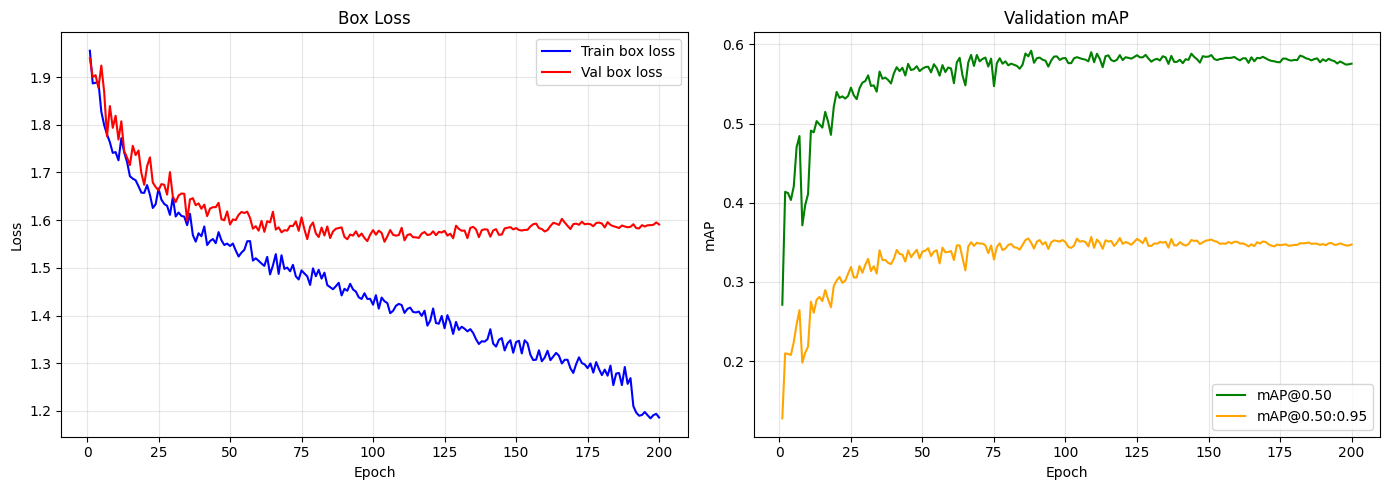

Графики сохранены в: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/runs_yolo/text_detector_unet_png/training_curles.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# YOLO сохраняет results.csv в папку run
run_dir = Path(
    "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/"
    "runs_yolo/text_detector_unet_png"
)
results_csv = run_dir / "results.csv"

df = pd.read_csv(results_csv)
# Убираем лишние пробелы в названиях колонок
df.columns = df.columns.str.strip()

epochs = df["epoch"].values

# --- График Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box loss
axes[0].plot(epochs, df["train/box_loss"], label="Train box loss", color="blue")
axes[0].plot(epochs, df["val/box_loss"],   label="Val box loss",   color="red")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Box Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP50
axes[1].plot(epochs, df["metrics/mAP50(B)"], label="mAP@0.50", color="green")
axes[1].plot(epochs, df["metrics/mAP50-95(B)"], label="mAP@0.50:0.95", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("Validation mAP")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Графики сохранены в:", run_dir / "training_curles.png")

#7. КАРТИНКА: Ground Truth vs Predicted (бок о бок)

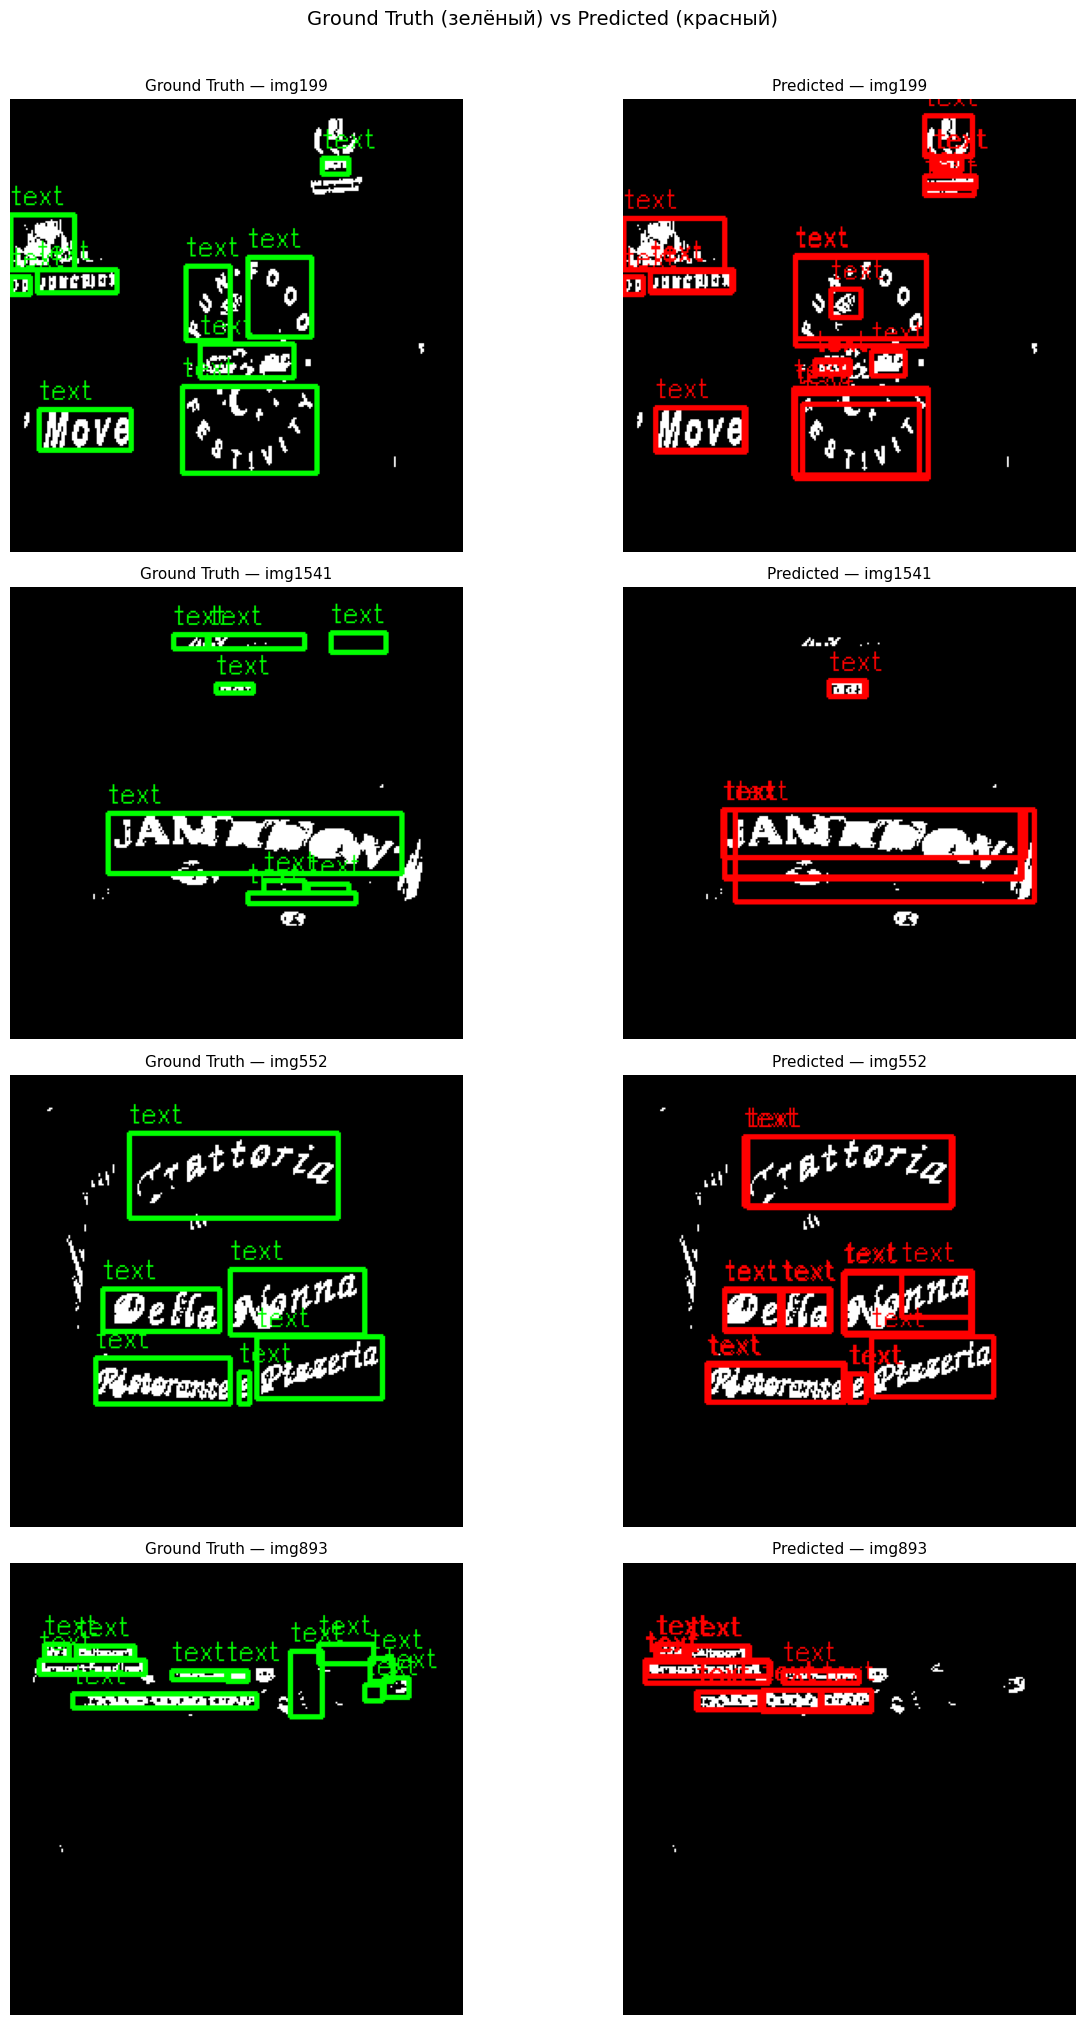

Сравнение GT vs Pred сохранено в: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/runs_yolo/text_detector_unet_png/gt_vs_pred.png


In [ ]:
import cv2
import numpy as np
import random

def draw_yolo_boxes_on_image(image_path, label_path, color=(0, 255, 0), thickness=2):
    """Рисует YOLO-боксы на копии изображения."""
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    h, w = img.shape[:2]

    if Path(label_path).exists():
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(float(parts[0]))
                cx, cy, bw, bh = map(float, parts[1:])

                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                x2 = int((cx + bw / 2) * w)
                y2 = int((cy + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
                label_text = f"{names[cls] if cls < len(names) else cls}"
                cv2.putText(img, label_text, (x1, y1 - 6),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img


# Берём несколько случайных изображений из val
val_img_dir = yolo_dataset_root / "images" / "val"
val_lbl_dir = yolo_dataset_root / "labels" / "val"
pred_lbl_dir = Path(
    "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/"
    "yolo_predictions/val_predictions/labels"
)

val_images = sorted(val_img_dir.glob("*.png"))
n_show = min(4, len(val_images))  # покажем до 4 картинок
sample_images = random.sample(val_images, n_show)

fig, axes = plt.subplots(n_show, 2, figsize=(14, 5 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]  # чтобы индексация работала

for i, img_path in enumerate(sample_images):
    stem = img_path.stem

    # Ground Truth
    gt_label = val_lbl_dir / f"{stem}.txt"
    gt_img = draw_yolo_boxes_on_image(img_path, gt_label, color=(0, 255, 0))

    # Predicted
    pred_label = pred_lbl_dir / f"{stem}.txt"
    pred_img = draw_yolo_boxes_on_image(img_path, pred_label, color=(0, 0, 255))

    axes[i, 0].imshow(cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"Ground Truth — {stem}", fontsize=11)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f"Predicted — {stem}", fontsize=11)
    axes[i, 1].axis("off")

plt.suptitle("Ground Truth (зелёный) vs Predicted (красный)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(run_dir / "gt_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сравнение GT vs Pred сохранено в:", run_dir / "gt_vs_pred.png")